In [1]:
import xarray as xr
import pandas as pd
import numpy as np

from glob import glob
from stericheight.data_handler import GEBCO

In [2]:
files=glob('../data/sip/*.asci')

In [3]:
elevation_ = GEBCO(coarsen_factor=4).ds.elevation

In [4]:
# check lats and lons are always the same
first=True
for f in files:
    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    lats = data['lat']
    lons = data['lon']
    if not first:
        if (sum(lats-lastlat) > 0) or (sum(lons-lastlon) >0):
            print(f)
            break
    lastlat = lats
    lastlon = lons
    first=False



In [5]:
times=[]
alldata=[]#np.array([len(lats),len(files)])
for n,f in enumerate(files):
    filedate=str.split(f,'/')[3].split('.')[0]
    yyyy=filedate[0:4]
    mm=filedate[4:6]
    times.append(pd.Timestamp(int(yyyy),int(mm),1))

    data = pd.read_csv(f,sep='\\s+',names=['lon','lat','ice'])
    # data['ice'].to_xarray().assign_coords({'time':pd.Timestamp(int(yyyy),int(mm),1)})
    alldata.append(data['ice'].to_list())    



In [6]:
sip=xr.DataArray(data=alldata,coords={'time':times,'index':np.arange(len(data))})
sip_ds=xr.Dataset(data_vars={'sip':sip,'lat':xr.DataArray(data=lats,coords={'index':sip.index}),'lon':xr.DataArray(data=lons,coords={'index':sip.index})})

In [7]:
sip = sip.assign_coords({'lat':sip_ds.lat,'lon':sip_ds.lon})

In [29]:
elevation = elevation_.sel(latitude = slice(sip.lat.min(), sip.lat.max()), longitude = slice(sip.lon.min(),sip.lon.max()))

In [31]:
sip['elevation']=elevation.interp(latitude=sip.lat,longitude=sip.lon)

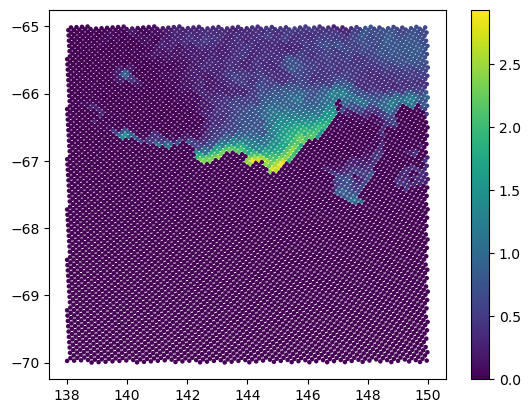

In [32]:
import matplotlib.pyplot as plt

t0 = sip.isel(time=0)

plt.scatter(t0.lon, t0.lat, c=t0, s=5)
plt.colorbar()
plt.show()

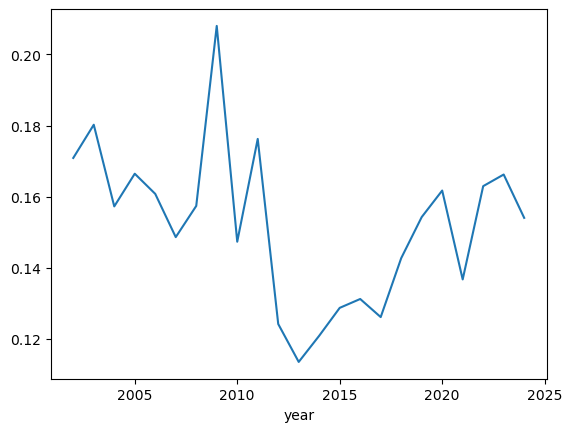

In [11]:
sip.mean('index').groupby('time.year').mean().plot()

In [33]:
sip.to_netcdf('sip.nc')

In [64]:
nlon = len(np.unique(sip.lon))
nlat = len(np.unique(sip.lat))

print(nlon, nlat)
print(nlon * nlat)
print(len(sip.index))

7276 6502
47308552
7443


In [ ]:
pd.read_csv('../data/sip/201705.monthly.icepro.antarctic_Mertz.asci',delim_whitespace=True,names=['a','b','c'])

/tmp/ipykernel_55625/1080712711.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv('../data/sip/201705.monthly.icepro.antarctic_Mertz.asci',delim_whitespace=True,names=['a','b','c'])


,a,b,c
0,138.006714,-69.976219,0.000000
1,138.237518,-69.971901,0.000000
2,138.115845,-69.934547,0.000000
3,138.468231,-69.967270,0.000000
4,138.346146,-69.930092,0.000000
...,...,...,...
7438,149.955231,-65.090485,0.693147
7439,149.842224,-65.062851,0.650368
7440,149.729477,-65.035118,0.655421
7441,149.616989,-65.007301,0.667139
